# Part I: Preprocessing

## Basic settings

In [87]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [88]:
import os
import sys
import warnings
from datetime import datetime, timedelta

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.options.display.max_rows = 50
pd.options.display.max_columns = None

In [89]:
src_path = os.path.abspath("..")
if src_path not in sys.path:
    sys.path.append(src_path)

In [90]:
src_path

'c:\\Users\\voqua\\Downloads\\Python\\sales_forecasting_research'

In [91]:
from data.data_generator import check_missing_values
from utils.plots import plot_sales
from utils.utils import get_sample_stores, fill_missing_sales_hierarchical, correct_outliers_hierarchical

In [92]:
DATA_DIR = "../data"

## Load and clean data

In [93]:
dt_topic = ['sales','weather','holiday','promotion']
# Load all datasets
for x in dt_topic:
    globals()[f"df_{x}"] = pd.read_csv(os.path.join(DATA_DIR, f"{x}_data.csv"))
    print("==================================================================================")
    print(f"df_{x}:")
    print(display(globals()[f"df_{x}"]))
    print(f"datatype of df_{x}:")
    print(globals()[f"df_{x}"].dtypes)

df_sales:


,date,province,store_id,store_name,category,item_id,item_name,price,base_price,is_promotion,promo_id,sales
0,2023-01-01,New South Wales,1,Sydney CBD,Staples,1,Long Grain Rice 2kg,5.50,5.50,0,0,10.0
1,2023-01-02,New South Wales,1,Sydney CBD,Staples,1,Long Grain Rice 2kg,5.50,5.50,0,0,14.0
2,2023-01-03,New South Wales,1,Sydney CBD,Staples,1,Long Grain Rice 2kg,5.50,5.50,0,0,10.0
3,2023-01-04,New South Wales,1,Sydney CBD,Staples,1,Long Grain Rice 2kg,5.50,5.50,0,0,14.0
4,2023-01-05,New South Wales,1,Sydney CBD,Staples,1,Long Grain Rice 2kg,5.50,5.50,0,0,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...
394555,2025-12-27,South Australia,12,Noarlunga,Household,30,Firelighters 24pk,6.27,6.27,0,0,3.0
394556,2025-12-28,South Australia,12,Noarlunga,Household,30,Firelighters 24pk,6.27,6.27,0,0,2.0
394557,2025-12-29,South Australia,12,Noarlunga,Household,30,Firelighters 24pk,6.27,6.27,0,0,3.0
394558,2025-12-30,South Australia,12,Noarlunga,Household,30,Firelighters 24pk,6.28,6.28,0,0,0.0


None
datatype of df_sales:
date             object
province         object
store_id          int64
store_name       object
category         object
item_id           int64
item_name        object
price           float64
base_price      float64
is_promotion      int64
promo_id          int64
sales           float64
dtype: object
df_weather:


,date,city,province,temperature,humidity,season
0,2023-01-01,Sydney,New South Wales,18.3,70.2,Summer
1,2023-01-02,Sydney,New South Wales,18.5,63.2,Summer
2,2023-01-03,Sydney,New South Wales,14.7,74.6,Summer
3,2023-01-04,Sydney,New South Wales,15.6,71.6,Summer
4,2023-01-05,Sydney,New South Wales,19.3,71.8,Summer
...,...,...,...,...,...,...
4379,2025-12-27,Adelaide,South Australia,20.3,42.0,Summer
4380,2025-12-28,Adelaide,South Australia,19.0,43.3,Summer
4381,2025-12-29,Adelaide,South Australia,13.0,33.9,Summer
4382,2025-12-30,Adelaide,South Australia,16.4,37.6,Summer


None
datatype of df_weather:
date            object
city            object
province        object
temperature    float64
humidity       float64
season          object
dtype: object
df_holiday:


,date,province,day_of_week,is_weekend,is_public_holiday,holiday_name,is_school_holiday
0,2023-01-01,New South Wales,Sunday,1,1,New Year's Day,1
1,2023-01-01,Victoria,Sunday,1,1,New Year's Day,1
2,2023-01-01,Queensland,Sunday,1,1,New Year's Day,1
3,2023-01-01,South Australia,Sunday,1,1,New Year's Day,1
4,2023-01-02,New South Wales,Monday,0,0,NaN,1
...,...,...,...,...,...,...,...
4379,2025-12-30,South Australia,Tuesday,0,0,NaN,1
4380,2025-12-31,New South Wales,Wednesday,0,0,NaN,1
4381,2025-12-31,Victoria,Wednesday,0,0,NaN,1
4382,2025-12-31,Queensland,Wednesday,0,0,NaN,1


None
datatype of df_holiday:
date                 object
province             object
day_of_week          object
is_weekend            int64
is_public_holiday     int64
holiday_name         object
is_school_holiday     int64
dtype: object
df_promotion:


,promo_id,store_id,store_name,province,item_id,item_name,category,start_date,end_date,duration_days,discount_pct,promo_type
0,1,1,Sydney CBD,New South Wales,1,Long Grain Rice 2kg,Staples,2023-07-03,2023-07-10,8,20.0,Catalogue
1,2,1,Sydney CBD,New South Wales,1,Long Grain Rice 2kg,Staples,2023-01-29,2023-02-09,12,30.0,Catalogue
2,3,1,Sydney CBD,New South Wales,1,Long Grain Rice 2kg,Staples,2025-01-12,2025-01-20,9,20.0,Catalogue
3,4,1,Sydney CBD,New South Wales,1,Long Grain Rice 2kg,Staples,2025-03-07,2025-03-19,13,50.0,Clearance
4,5,1,Sydney CBD,New South Wales,1,Long Grain Rice 2kg,Staples,2025-04-25,2025-05-02,8,50.0,Clearance
...,...,...,...,...,...,...,...,...,...,...,...,...
7172,7173,12,Noarlunga,South Australia,30,Firelighters 24pk,Household,2023-12-05,2023-12-11,7,10.0,In-Store Display
7173,7174,12,Noarlunga,South Australia,30,Firelighters 24pk,Household,2023-01-01,2023-01-13,13,50.0,Clearance
7174,7175,12,Noarlunga,South Australia,30,Firelighters 24pk,Household,2024-09-28,2024-10-06,9,30.0,Catalogue
7175,7176,12,Noarlunga,South Australia,30,Firelighters 24pk,Household,2024-06-26,2024-07-06,11,50.0,Clearance


None
datatype of df_promotion:
promo_id           int64
store_id           int64
store_name        object
province          object
item_id            int64
item_name         object
category          object
start_date        object
end_date          object
duration_days      int64
discount_pct     float64
promo_type        object
dtype: object


In [94]:
# Convert date columns from object to datatime
for x in dt_topic:
   for col in globals()[f'df_{x}'].columns:
      if 'date' in col.lower():
        globals()[f'df_{x}'][col] = pd.to_datetime(globals()[f'df_{x}'][col])
        print(f'variable {col} in df_{x} has been converted into datetime')

variable date in df_sales has been converted into datetime
variable date in df_weather has been converted into datetime
variable date in df_holiday has been converted into datetime
variable start_date in df_promotion has been converted into datetime
variable end_date in df_promotion has been converted into datetime


### Check if all flag variable are binary


In [95]:
for x in dt_topic:
   for col in globals()[f'df_{x}'].columns:
      if 'is_' in col.lower():
        print(f'dataframe df_{x}: {globals()[f'df_{x}'][col].value_counts()}')

dataframe df_sales: is_promotion
0    327406
1     67154
Name: count, dtype: int64
dataframe df_holiday: is_weekend
0    3132
1    1252
Name: count, dtype: int64
dataframe df_holiday: is_public_holiday
0    4258
1     126
Name: count, dtype: int64
dataframe df_holiday: is_school_holiday
0    3304
1    1080
Name: count, dtype: int64


### Convert all flag variales into binary

In [96]:
for x in dt_topic:
   for col in globals()[f'df_{x}'].columns:
      if 'is_' in col.lower():
        globals()[f'df_{x}'][col] = globals()[f'df_{x}'][col].astype(bool)
        print(f'{col} in the dataframe df_{x} has been converted into Boolean')

is_promotion in the dataframe df_sales has been converted into Boolean
is_weekend in the dataframe df_holiday has been converted into Boolean
is_public_holiday in the dataframe df_holiday has been converted into Boolean
is_school_holiday in the dataframe df_holiday has been converted into Boolean


### Check missing dates

In [97]:
for x in dt_topic:

    for col in globals()[f'df_{x}'].columns:
      if col.lower() == 'date':
        date_range = pd.date_range(start = globals()[f'df_{x}'][col].min(),
                           end = globals()[f'df_{x}'][col].max(),
                           freq = 'D' ) 
        missing_dates = date_range.difference(globals()[f'df_{x}'][col].dropna().unique())
        print(f'Check missing dates in {col} in the dataframe df_{x}')
        print(missing_dates)




Check missing dates in date in the dataframe df_sales
DatetimeIndex([], dtype='datetime64[ns]', freq='D')
Check missing dates in date in the dataframe df_weather
DatetimeIndex([], dtype='datetime64[ns]', freq='D')
Check missing dates in date in the dataframe df_holiday
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


### Add day_of_week in df_sales

In [98]:
df_sales["day_of_week"] = df_sales["date"].dt.dayofweek

### Handling missing values

In [99]:
# Check missing values for each df
for x in dt_topic:
    display(check_missing_values(globals()[f'df_{x}'], f"df={x}"))

  df=sales: sales has 3,945 missing (1.00%)


None

  df=weather: no missing values


None

  df=holiday: holiday_name has 4,258 missing (97.13%)


None

  df=promotion: no missing values


None

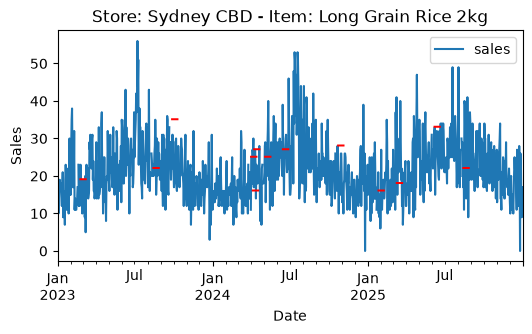

In [100]:
# Checking nan values and outliers in a plot
plot_sales(df_sales, store_id=1, item_id=1)

In [101]:
# Fill nan using mean values
df_sales_filled = fill_missing_sales_hierarchical(df_sales)

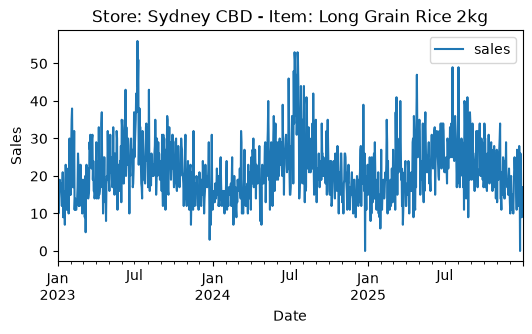

In [102]:
# Checking nan values and outliers in a plot
plot_sales(df_sales_filled, store_id=1, item_id=1)

In [103]:
# Check missing values
display(check_missing_values(df_sales_filled, "df=sales"))

  df=sales: no missing values


None

In [104]:
df_sales_filled[df_sales_filled["sales"].isna()]

,date,province,store_id,store_name,category,item_id,item_name,price,base_price,is_promotion,promo_id,sales,day_of_week


### Check and correct outliers

In [105]:
df_sales_filled

,date,province,store_id,store_name,category,item_id,item_name,price,base_price,is_promotion,promo_id,sales,day_of_week
0,2023-01-01,New South Wales,1,Sydney CBD,Staples,1,Long Grain Rice 2kg,5.50,5.50,False,0,10.0,6
1,2023-01-02,New South Wales,1,Sydney CBD,Staples,1,Long Grain Rice 2kg,5.50,5.50,False,0,14.0,0
2,2023-01-03,New South Wales,1,Sydney CBD,Staples,1,Long Grain Rice 2kg,5.50,5.50,False,0,10.0,1
3,2023-01-04,New South Wales,1,Sydney CBD,Staples,1,Long Grain Rice 2kg,5.50,5.50,False,0,14.0,2
4,2023-01-05,New South Wales,1,Sydney CBD,Staples,1,Long Grain Rice 2kg,5.50,5.50,False,0,17.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
394555,2025-12-27,South Australia,12,Noarlunga,Household,30,Firelighters 24pk,6.27,6.27,False,0,3.0,5
394556,2025-12-28,South Australia,12,Noarlunga,Household,30,Firelighters 24pk,6.27,6.27,False,0,2.0,6
394557,2025-12-29,South Australia,12,Noarlunga,Household,30,Firelighters 24pk,6.27,6.27,False,0,3.0,0
394558,2025-12-30,South Australia,12,Noarlunga,Household,30,Firelighters 24pk,6.28,6.28,False,0,0.0,1


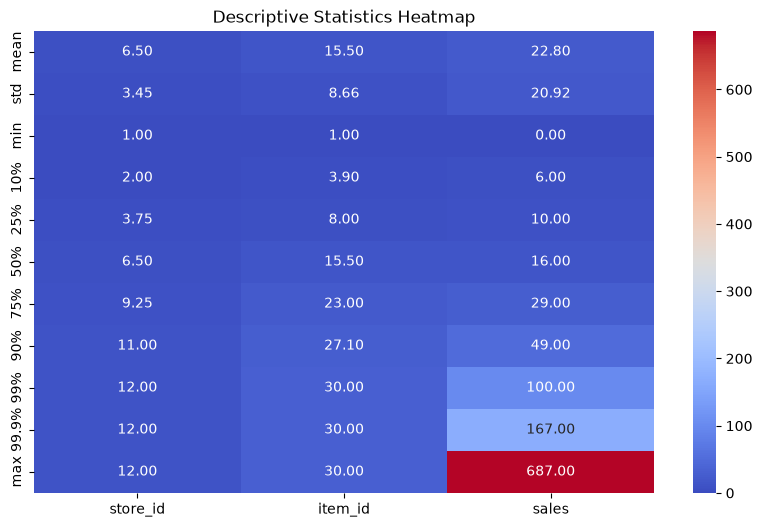

In [106]:
# Using heat map to visualize outliers
summary = (
    df_sales_filled[["store_id", "item_id", "sales"]]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999])
    .iloc[1:]
)

plt.figure(figsize=(10, 6))
sns.heatmap(summary, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Descriptive Statistics Heatmap")
plt.show()

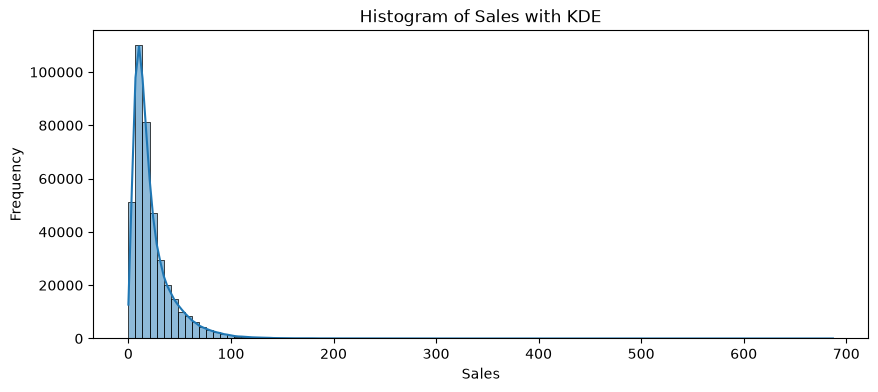

In [107]:
# plot the histogram
plt.figure(figsize=(10, 4))
sns.histplot(df_sales_filled["sales"], bins=100, kde=True)
plt.title("Histogram of Sales with KDE")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

In [108]:
# Correct outliers
df_sales_corrected = correct_outliers_hierarchical(df=df_sales_filled)

In [109]:
# Check if outliers were corrected properly
summary = (
    df_sales_corrected[["store_id", "item_id", "sales"]]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999])
    .iloc[1:]
)
display(summary)

,store_id,item_id,sales
mean,6.500000,15.500000,22.239387
std,3.452057,8.655452,19.527597
min,1.000000,1.000000,0.000000
10%,2.000000,3.900000,6.000000
25%,3.750000,8.000000,9.000000
50%,6.500000,15.500000,16.000000
75%,9.250000,23.000000,28.000000
90%,11.000000,27.100000,48.000000
99%,12.000000,30.000000,94.000000
99.9%,12.000000,30.000000,136.000000


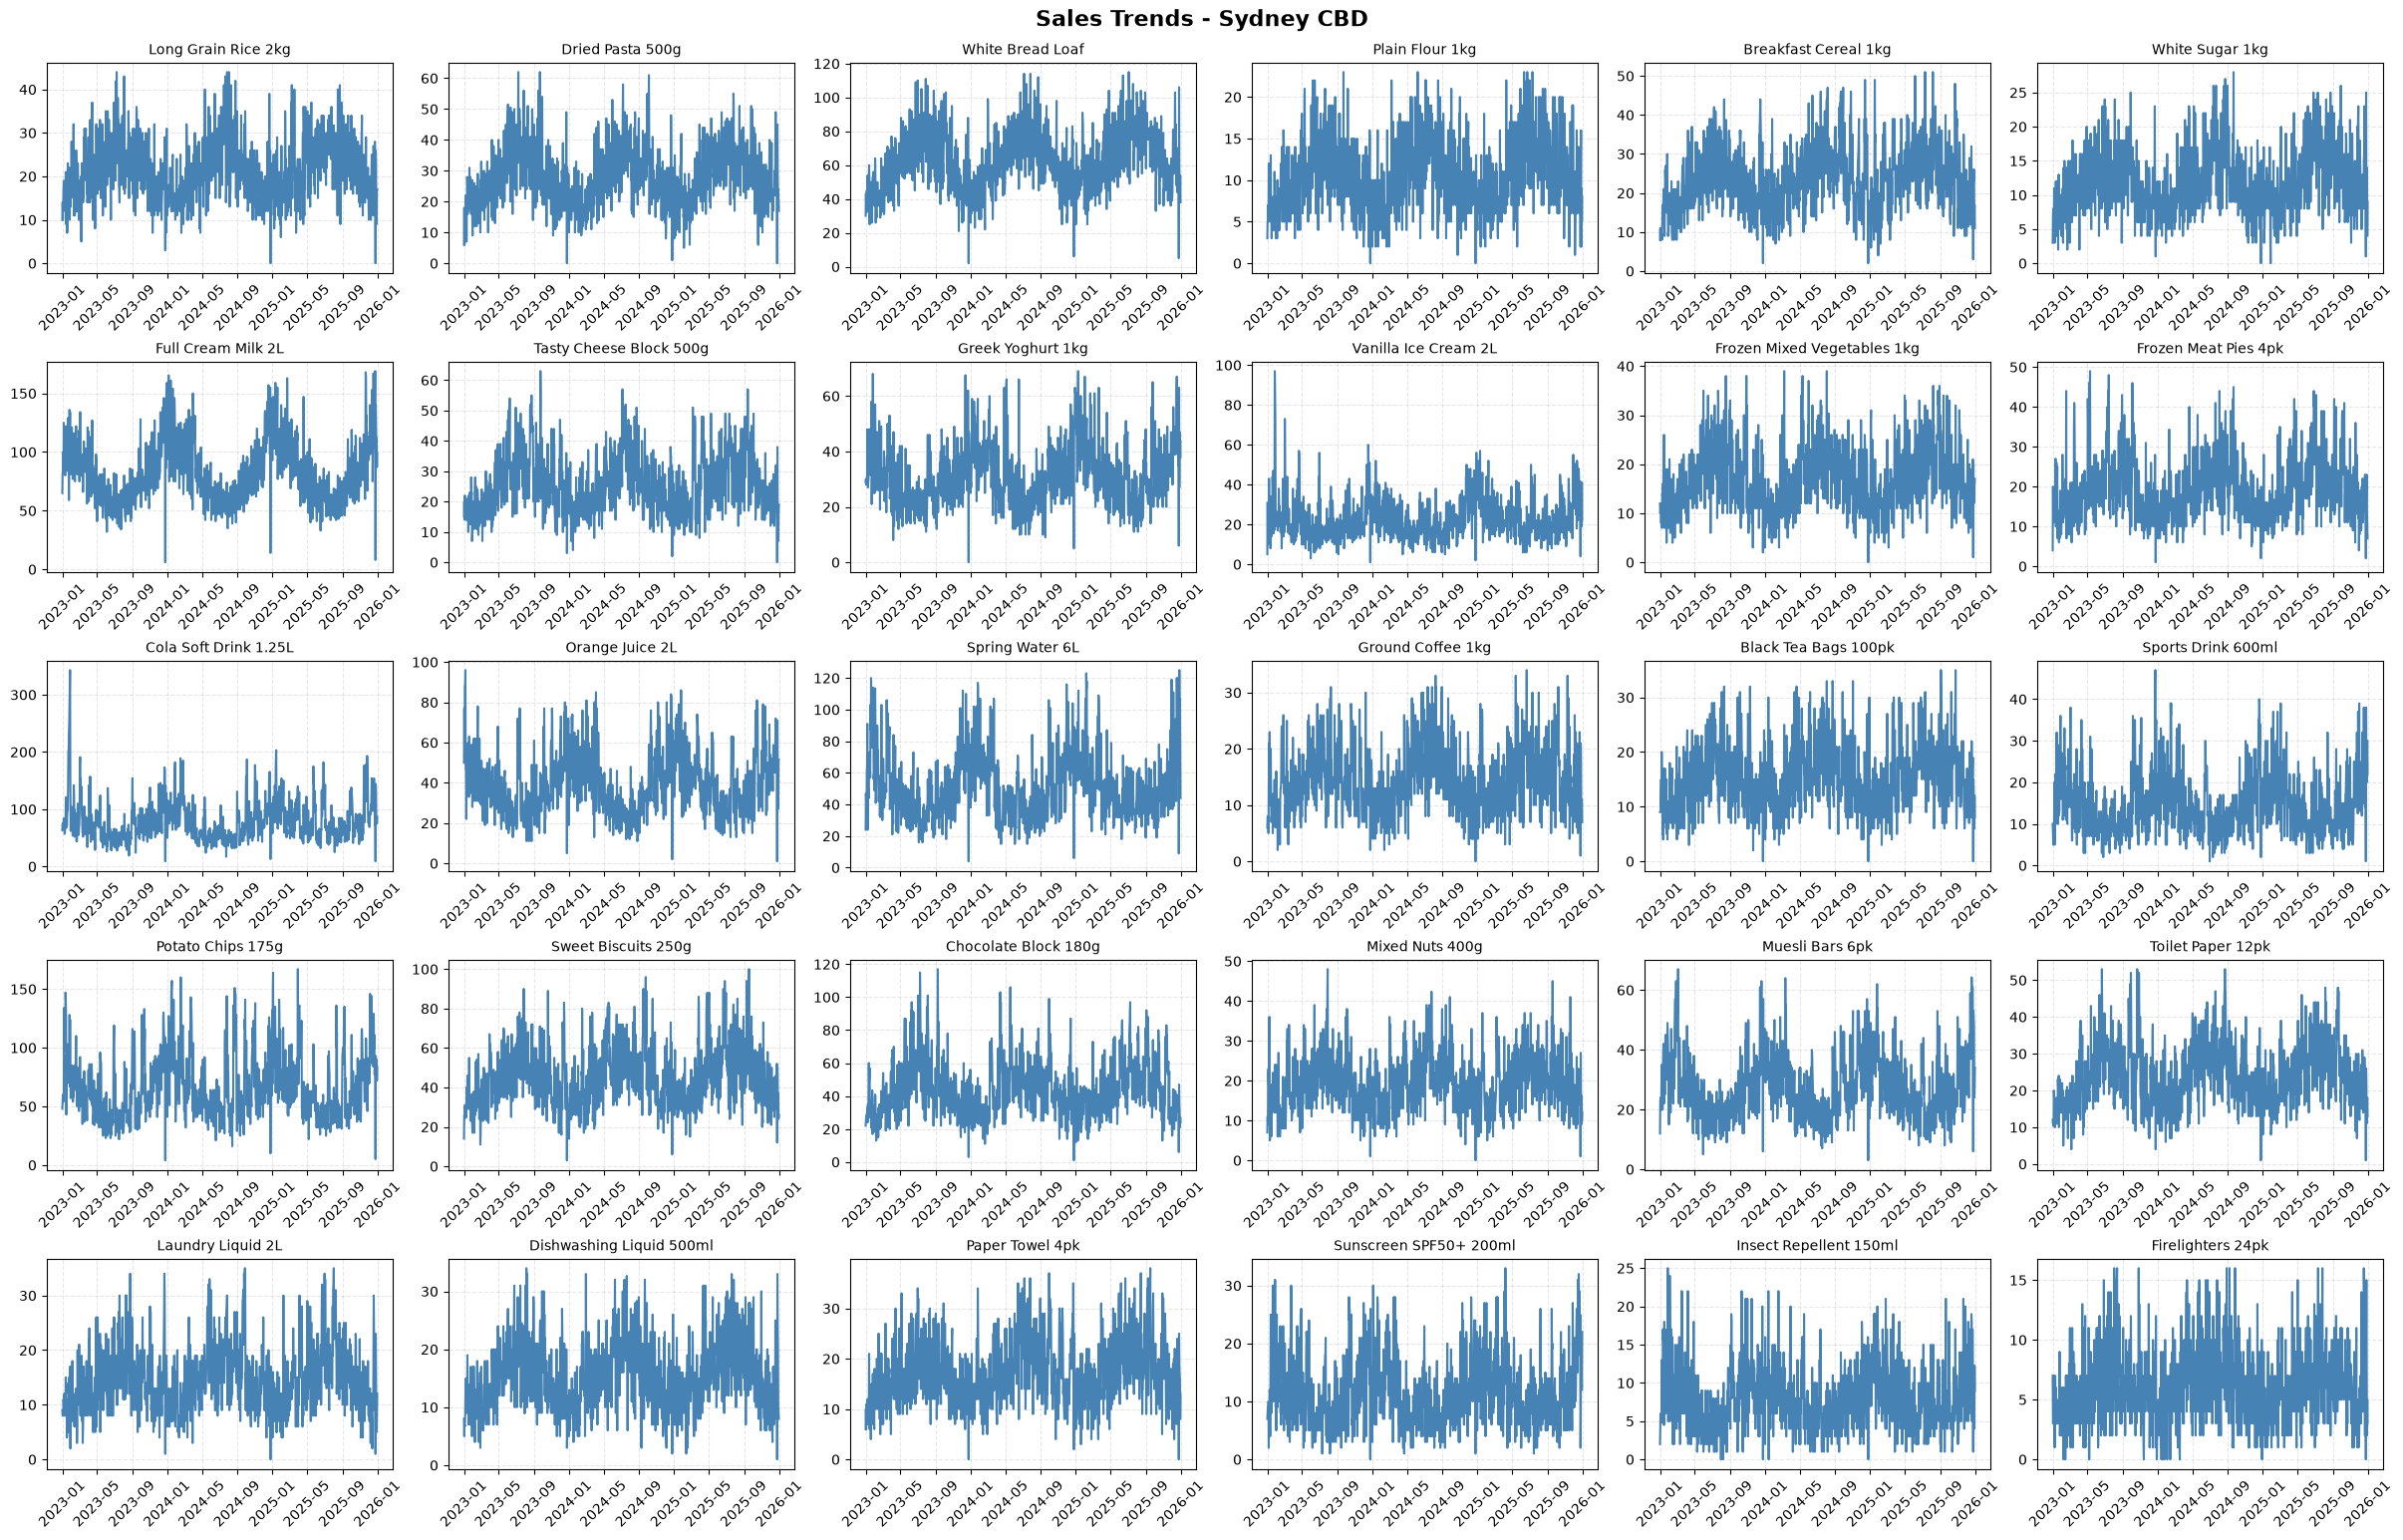

In [110]:
# Get targeted store
store_id = 1
df_sample_store = get_sample_stores(df_sales_corrected, store_id=store_id)
store_name = df_sample_store["store_name"].iloc[-1]

# Grid layout
nrows, ncols = 5, 6
fig, axes = plt.subplots(
    nrows, ncols, figsize=(ncols * 4, nrows * 3), constrained_layout=True
)
axes = axes.flatten()

lst_items = df_sample_store["item_id"].unique().tolist()

for idx, (item_id, ax) in enumerate(zip(lst_items, axes)):
    df2plot = df_sample_store.query("item_id == @item_id")
    item_name = df2plot["item_name"].iloc[-1]

    ax.plot(df2plot["date"], df2plot["sales"], color="steelblue", linewidth=1.5)
    ax.set_title(f"{item_name}", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, linestyle="--", alpha=0.3)

# Hide unused subplots
for ax in axes[len(lst_items) :]:
    ax.axis("off")

# Main title
fig.suptitle(f"Sales Trends - {store_name}", fontsize=16, fontweight="bold", y=1.02)
plt.show()

In [111]:
check_missing_values(df_sales_corrected, "df=sales_corrected")

  df=sales_corrected: no missing values


### Quick check of categorical variable

In [112]:
for x in dt_topic:
    df = globals().get(f"df_{x}")
    if df is None:
        continue

    print(f"\n=== {x} ===")
    obj_cols = df.select_dtypes(include=["object", "category"]).columns

    for col in obj_cols:
        nunique = df[col].nunique(dropna=True)
        if nunique < 40:
            vals = df[col].dropna().unique()
            print(f"\n{col} ({df[col].dtype}):")
            print(sorted([str(v) for v in vals]))


=== sales ===

province (object):
['New South Wales', 'Queensland', 'South Australia', 'Victoria']

store_name (object):
['Adelaide CBD', 'Brisbane CBD', 'Chatswood', 'Chermside', 'Dandenong', 'Footscray', 'Logan', 'Melbourne CBD', 'Modbury', 'Noarlunga', 'Parramatta', 'Sydney CBD']

category (object):
['Beverages', 'Dairy & Frozen', 'Household', 'Snacks', 'Staples']

item_name (object):
['Black Tea Bags 100pk', 'Breakfast Cereal 1kg', 'Chocolate Block 180g', 'Cola Soft Drink 1.25L', 'Dishwashing Liquid 500ml', 'Dried Pasta 500g', 'Firelighters 24pk', 'Frozen Meat Pies 4pk', 'Frozen Mixed Vegetables 1kg', 'Full Cream Milk 2L', 'Greek Yoghurt 1kg', 'Ground Coffee 1kg', 'Insect Repellent 150ml', 'Laundry Liquid 2L', 'Long Grain Rice 2kg', 'Mixed Nuts 400g', 'Muesli Bars 6pk', 'Orange Juice 2L', 'Paper Towel 4pk', 'Plain Flour 1kg', 'Potato Chips 175g', 'Sports Drink 600ml', 'Spring Water 6L', 'Sunscreen SPF50+ 200ml', 'Sweet Biscuits 250g', 'Tasty Cheese Block 500g', 'Toilet Paper 12pk'

In [113]:
# Continuous-variable percentiles for each table
tables = {}

for x in dt_topic:
    tables[f"df_{x}"] = globals().get(f"df_{x}")

percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

for table_name, df in tables.items():
    numeric_cols = [
        c for c in df.columns
        if pd.api.types.is_numeric_dtype(df[c]) and not pd.api.types.is_bool_dtype(df[c])
    ]

    if not numeric_cols:
        print(f"\n=== {table_name} ===")
        print("No continuous numeric variables.")
        continue

    rows = []
    for col in numeric_cols:
        s = df[col].dropna()
        if s.empty:
            continue

        row = {"variable": col, "min": s.min()}
        for p in percentiles:
            row[f"p{int(p * 100):02d}"] = s.quantile(p)
        row["max"] = s.max()
        rows.append(row)

    summary = pd.DataFrame(rows).set_index("variable")
    summary = summary.reindex(
        columns=["min"] + [f"p{int(p * 100):02d}" for p in percentiles] + ["max"]
    )

    print(f"\n=== {table_name} ===")
    display(summary.round(4))


=== df_sales ===


,min,p01,p05,p10,p25,p50,p75,p90,p95,p99,max
variable,,,,,,,,,,,
store_id,1.00,1.00,1.00,2.000,3.75,6.50,9.25,11.000,12.00,12.00,12.0
item_id,1.00,1.00,2.00,3.900,8.00,15.50,23.00,27.100,29.00,30.00,30.0
price,1.14,2.20,2.49,2.750,3.98,5.05,7.35,10.090,12.56,23.90,25.1
base_price,2.20,2.29,2.53,3.165,4.25,5.22,7.58,10.343,12.82,24.13,25.1
promo_id,0.00,0.00,0.00,0.000,0.00,0.00,0.00,2947.000,5029.05,6752.00,7177.0
sales,0.00,2.00,4.00,6.000,10.00,16.00,29.00,49.000,64.00,100.00,687.0
day_of_week,0.00,0.00,0.00,0.000,1.00,3.00,5.00,6.000,6.00,6.00,6.0



=== df_weather ===


,min,p01,p05,p10,p25,p50,p75,p90,p95,p99,max
variable,,,,,,,,,,,
temperature,-1.0,4.5,8.5,10.8,14.4,18.3,22.3,25.1,26.7,29.1,34.1
humidity,31.3,38.4,46.5,51.4,58.6,65.3,71.2,76.0,79.2,84.5,96.3



=== df_holiday ===
No continuous numeric variables.

=== df_promotion ===


,min,p01,p05,p10,p25,p50,p75,p90,p95,p99,max
variable,,,,,,,,,,,
promo_id,1.0,72.76,359.8,718.6,1795.0,3589.0,5383.0,6459.4,6818.2,7105.24,7177.0
store_id,1.0,1.00,1.0,2.0,4.0,7.0,10.0,11.0,12.0,12.00,12.0
item_id,1.0,1.00,3.0,5.0,11.0,17.0,23.0,27.0,28.0,30.00,30.0
duration_days,5.0,5.00,5.0,5.0,7.0,9.0,12.0,13.0,14.0,14.00,14.0
discount_pct,10.0,10.00,10.0,10.0,15.0,20.0,25.0,30.0,30.0,50.00,50.0


### Weather data

`weather_data.csv` already contains a `province` column, so **no rename is needed**.
Renaming `city` to `province` would produce two columns with the same name and
break every downstream join.

The join key is `["date", "province"]`.

In [114]:
# Sanity check the join key BEFORE merging. A silent key mismatch produces an
# all-NaN join rather than an error, which is easy to miss.
print("weather province values:", sorted(df_weather["province"].unique()))
print("sales   province values:", sorted(df_sales["province"].unique()))
assert set(df_weather["province"]) == set(df_sales["province"]), "province mismatch"

print("\ncity -> province mapping already in the file:")
display(df_weather[["city", "province"]].drop_duplicates().reset_index(drop=True))

weather province values: ['New South Wales', 'Queensland', 'South Australia', 'Victoria']
sales   province values: ['New South Wales', 'Queensland', 'South Australia', 'Victoria']

city -> province mapping already in the file:


,city,province
0,Sydney,New South Wales
1,Melbourne,Victoria
2,Brisbane,Queensland
3,Adelaide,South Australia


#### Temperature anomaly

Raw `temperature` is not comparable across cities. A 25 °C day is mild in Brisbane
(July mean 21 °C) and hot in Melbourne (July mean 10 °C), so a model given raw
temperature has to learn the city-specific baseline before it can learn the weather
response.

`temp_anomaly` is the deviation from that city's own norm for that month. This is a
deterministic recoding, not a fitted transform, so computing it here does not leak.

In [115]:
# City-and-month norms, then the anomaly against them.
df_weather["month"] = df_weather["date"].dt.month

norms = (
    df_weather.groupby(["province", "month"])["temperature"]
    .mean()
    .rename("temp_norm")
    .reset_index()
)

df_weather = df_weather.merge(norms, on=["province", "month"], how="left")
df_weather["temp_anomaly"] = (
    df_weather["temperature"] - df_weather["temp_norm"]
).round(2)

# Humidity above 80% acts as the wet-weather proxy in this dataset.
df_weather["is_humid"] = (df_weather["humidity"] > 80).astype(int)

display(
    df_weather.groupby("province")[["temperature", "temp_anomaly", "is_humid"]]
    .agg(["mean", "min", "max"])
    .round(2)
)

temperature            temp_anomaly               is_humid  \
                       mean  min   max         mean    min    max     mean   
province                                                                     
New South Wales       18.46  5.9  31.9          0.0  -9.37   9.60     0.04   
Queensland            21.39  9.9  31.9          0.0  -8.02   7.39     0.03   
South Australia       17.54 -0.5  34.1         -0.0 -11.97  13.88     0.02   
Victoria              15.08 -1.0  31.2          0.0 -15.20  12.37     0.08   

                         
                min max  
province                 
New South Wales   0   1  
Queensland        0   1  
South Australia   0   1  
Victoria          0   1

In [116]:
# Season should be a category, not a string, and should not be one-hot encoded
# here. Encoders are fitted objects and belong inside the modelling pipeline so
# they can be fitted on training data only.
df_weather["season"] = df_weather["season"].astype("category")

print(df_weather.dtypes.to_string())
print("\nrows:", len(df_weather))
display(df_weather.head())

date            datetime64[ns]
city                    object
province                object
temperature            float64
humidity               float64
season                category
month                    int32
temp_norm              float64
temp_anomaly           float64
is_humid                 int64

rows: 4384


,date,city,province,temperature,humidity,season,month,temp_norm,temp_anomaly,is_humid
0,2023-01-01,Sydney,New South Wales,18.3,70.2,Summer,1,22.804301,-4.5,0
1,2023-01-02,Sydney,New South Wales,18.5,63.2,Summer,1,22.804301,-4.3,0
2,2023-01-03,Sydney,New South Wales,14.7,74.6,Summer,1,22.804301,-8.1,0
3,2023-01-04,Sydney,New South Wales,15.6,71.6,Summer,1,22.804301,-7.2,0
4,2023-01-05,Sydney,New South Wales,19.3,71.8,Summer,1,22.804301,-3.5,0


In [117]:
# make sure there are no weird values/typos in season
df_weather['season'].unique()

['Summer', 'Autumn', 'Winter', 'Spring']
Categories (4, object): ['Autumn', 'Spring', 'Summer', 'Winter']

### Holiday data

`check_missing_values` reports `holiday_name` as ~97% missing. **It is not missing.**
Every one of those rows has `is_public_holiday == 0` — there is no holiday to name.
This is structural absence, and imputing or dropping it would be wrong.

In [118]:
# Prove the NaNs are structural before deciding what to do with them.
n_nan = df_holiday["holiday_name"].isna().sum()
n_not_holiday = (df_holiday["is_public_holiday"] == 0).sum()
n_bad = ((df_holiday["is_public_holiday"] == 1) & df_holiday["holiday_name"].isna()).sum()

print(f"holiday_name NaN          : {n_nan:,}")
print(f"is_public_holiday == 0    : {n_not_holiday:,}")
print(f"holiday but unnamed (bad) : {n_bad:,}")
assert n_bad == 0, "a public holiday with no name would be a real data problem"

# Fill with an explicit label so the column is a clean categorical.
df_holiday["holiday_name"] = df_holiday["holiday_name"].fillna("None")
df_holiday["holiday_name"] = df_holiday["holiday_name"].astype("category")

holiday_name NaN          : 4,258
is_public_holiday == 0    : 4,258
holiday but unnamed (bad) : 0


In [119]:
df_holiday = df_holiday.sort_values(["province", "date"]).reset_index(drop=True)

# Days to the next public holiday and since the last one, computed per province
# because the holiday calendar genuinely differs by state.
#
# Done with an explicit loop rather than groupby.apply: recent pandas versions
# drop the grouping column inside apply, which silently breaks the result.
parts = []
for prov, g in df_holiday.groupby("province", sort=False):
    g = g.sort_values("date").copy()
    hol_dates = g.loc[g["is_public_holiday"] == 1, "date"].values
    d = g["date"].values[:, None]
    diff = (hol_dates[None, :] - d) / np.timedelta64(1, "D")
    g["days_to_holiday"] = np.clip(
        np.where(diff >= 0, diff, np.inf).min(axis=1), 0, 30
    ).astype(int)
    g["days_since_holiday"] = np.clip(
        np.where(diff <= 0, -diff, np.inf).min(axis=1), 0, 30
    ).astype(int)
    parts.append(g)

df_holiday = pd.concat(parts, ignore_index=True)

# The day before a closure is the pantry-loading day.CLOSURES = ["Christmas Day", "Good Friday", "New Year's Day", "ANZAC Day"]df_holiday["is_pre_holiday"] = (    (df_holiday["days_to_holiday"] == 1)    & df_holiday.groupby("province")["holiday_name"].shift(-1).isin(CLOSURES)).astype(int)# Christmas trading builds over the three weeks before 25 December.xmas = pd.to_datetime(df_holiday["date"].dt.year.astype(str) + "-12-25")days_to_xmas = (xmas - df_holiday["date"]).dt.daysdf_holiday["days_to_christmas"] = days_to_xmas.where(    (days_to_xmas >= 0) & (days_to_xmas <= 30), 99).astype(int)display(df_holiday.head(3))print("\nnew columns:", ["days_to_holiday", "days_since_holiday",                          "is_pre_holiday", "days_to_christmas"])

#### Keep the state-level variation

Labour Day is March in Victoria, May in Queensland, October in NSW and SA.
King's Birthday is June in three states and October in Queensland. Melbourne Cup is
Victoria only.

That means the same calendar date is a public holiday in one city and an ordinary
trading day in another, with weather and day-of-week held constant. Do **not**
collapse the holiday table to a national calendar — that variation is the closest
thing to a natural experiment in this dataset.

In [120]:
pivot = (
    df_holiday[df_holiday["is_public_holiday"] == 1]
    .assign(month=lambda d: d["date"].dt.strftime("%b"))
    .pivot_table(index="holiday_name", columns="province",
                 values="month", aggfunc="first", observed=True)
    .dropna(how="any")
)
display(pivot)

# Days that are a holiday in some states but not others.
by_date = df_holiday.groupby("date")["is_public_holiday"].agg(["sum", "size"])
split_days = by_date[(by_date["sum"] > 0) & (by_date["sum"] < by_date["size"])]
print(f"dates that are a holiday in some states but not all: {len(split_days)}")

province,New South Wales,Queensland,South Australia,Victoria
holiday_name,,,,
ANZAC Day,Apr,Apr,Apr,Apr
Australia Day,Jan,Jan,Jan,Jan
Boxing Day,Dec,Dec,Dec,Dec
Christmas Day,Dec,Dec,Dec,Dec
Easter Monday,Apr,Apr,Apr,Apr
Easter Saturday,Apr,Apr,Apr,Apr
Good Friday,Apr,Apr,Apr,Apr
King's Birthday,Jun,Oct,Jun,Jun
Labour Day,Oct,May,Oct,Mar


dates that are a holiday in some states but not all: 15


### Promotion data

`promotion_data.csv` is at **campaign** grain — one row per promotion, not per day.
`sales_data` already carries `is_promotion` and `promo_id`, so a simple model needs
no join at all. Join only when you want `promo_type` and `discount_pct`, which are
not in the sales table.

In [121]:
# Verify the key before relying on it.
promo_ids_in_sales = set(df_sales.loc[df_sales["promo_id"] > 0, "promo_id"].unique())
missing_ids = promo_ids_in_sales - set(df_promotion["promo_id"])
print(f"promo_ids in sales but not in promotion table: {len(missing_ids)}")

consistent = ((df_sales["promo_id"] > 0).astype(int) == df_sales["is_promotion"]).all()
print(f"is_promotion == (promo_id > 0): {consistent}")

# Derived: discount depth is available directly from the sales table.
df_sales_corrected["discount_pct"] = (
    (1 - df_sales_corrected["price"] / df_sales_corrected["base_price"]) * 100
).round(1)

display(df_promotion.groupby("promo_type")
        .agg(campaigns=("promo_id", "size"),
             mean_discount=("discount_pct", "mean"),
             mean_days=("duration_days", "mean")).round(1))

promo_ids in sales but not in promotion table: 0
is_promotion == (promo_id > 0): True


,campaigns,mean_discount,mean_days
promo_type,,,
Catalogue,3582,24.0,9.4
Clearance,284,50.0,9.2
In-Store Display,3311,12.5,9.3


## A note on what belongs here and what does not

Everything above is **deterministic feature engineering** — parsing dates, filling structural NaNs with a label, deriving calendar distances, and calculating temperature anomalies from a predefined or training-only baseline.

These transformations do not estimate parameters from the target data, so they do not introduce target leakage.

Two steps already in this notebook **do** estimate parameters from the full dataset, and both can leak future information into the training set:

| Step | Problem |
|---|---|
| `fill_missing_sales_hierarchical` | Fills missing sales values using a causal hierarchical approach. It first uses the mean of available historical sales for the same store_id, item_id, and calendar date, together with sales from the same weekday 1–2 weeks earlier. If unavailable, it falls back to the historical mean at the store-item, store, and overall levels. |
| `correct_outliers_hierarchical` |Identifies sales outliers within each store_id–item_id series using a causal z-score based only on previous observations. Detected outliers are then replaced using the same hierarchical historical-mean approach, progressing from date/weekday-level history to store-item, store, and overall historical means |


In [122]:
# Causal alternative to the mean fill: forward fill within each series, so only
# past values are ever used. Kept as a comparison rather than overwriting.
df_sales_ffill = df_sales.sort_values(["store_id", "item_id", "date"]).copy()
df_sales_ffill["sales"] = (
    df_sales_ffill.groupby(["store_id", "item_id"])["sales"].ffill()
)
# Any remaining NaN is at the very start of a series; back-fill just those.
df_sales_ffill["sales"] = (
    df_sales_ffill.groupby(["store_id", "item_id"])["sales"].bfill()
)

print("remaining NaN after causal fill:", int(df_sales_ffill["sales"].isna().sum()))
print("mean sales, mean-filled :", round(df_sales_filled["sales"].mean(), 3))
print("mean sales, ffill-filled:", round(df_sales_ffill["sales"].mean(), 3))

remaining NaN after causal fill: 0
mean sales, mean-filled : 22.801
mean sales, ffill-filled: 22.806


## Save preprocessed data

In [123]:
# Save all four preprocessed tables. The original notebook saved only sales and
# weather, which left holiday and promotion to be re-derived downstream.
outputs = {
    "sales_data_preprocessed.csv": df_sales_corrected,
    "weather_preprocessed.csv": df_weather,
    "holiday_preprocessed.csv": df_holiday,
    "promotion_preprocessed.csv": df_promotion,
}

for filename, frame in outputs.items():
    path = os.path.join(DATA_DIR, filename)
    frame.to_csv(path, index=False)
    print(f"{filename:34s} {len(frame):>8,} rows x {frame.shape[1]:>2} cols -> {path}")

sales_data_preprocessed.csv         394,560 rows x 14 cols -> ../data\sales_data_preprocessed.csv
weather_preprocessed.csv              4,384 rows x 10 cols -> ../data\weather_preprocessed.csv
holiday_preprocessed.csv              4,384 rows x  9 cols -> ../data\holiday_preprocessed.csv
promotion_preprocessed.csv            7,177 rows x 12 cols -> ../data\promotion_preprocessed.csv
